In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [12]:
df=pd.read_csv('iris.csv')
print(df.head())


   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [13]:
df.shape

(150, 5)

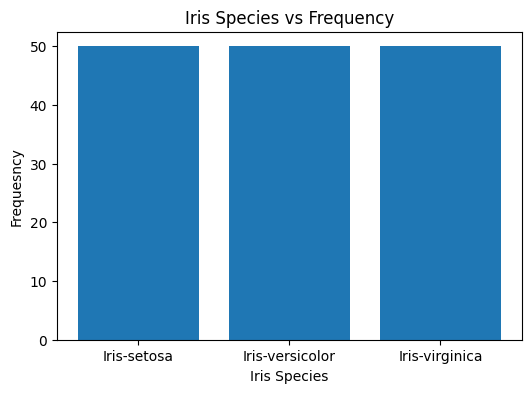

In [14]:
plt.figure(figsize=(6,4))
plt.bar(x=df['Species'].unique(), height=df['Species'].value_counts())
plt.xlabel("Iris Species")
plt.ylabel("Frequesncy")
plt.title("Iris Species vs Frequency")
plt.savefig('plot.png')
plt.show()

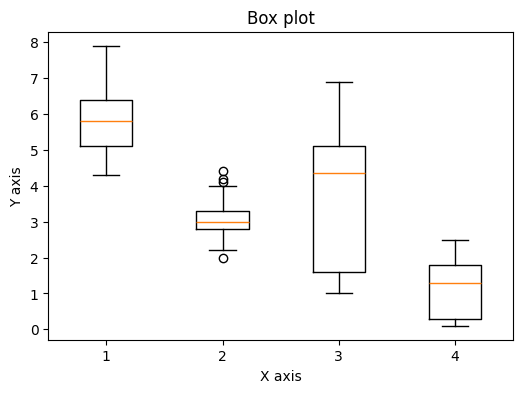

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df.drop(columns=['Species']));
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Box plot")
plt.savefig("boxplot.svg",format="svg")
plt.show()


In [16]:
#split into x and y
X= df.drop(columns=['Species'])
y=df["Species"]
#to dind the dimenionwe use 
# print(X.shape)
#X.shape

In [17]:
#split into training and testing set 
from sklearn.model_selection import train_test_split
X= df.drop(columns=['Species'])
y=df['Species']
print(X.shape)
print(y.shape)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=123)


(150, 4)
(150,)


In [18]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score , classification_report 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [19]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9666666666666667

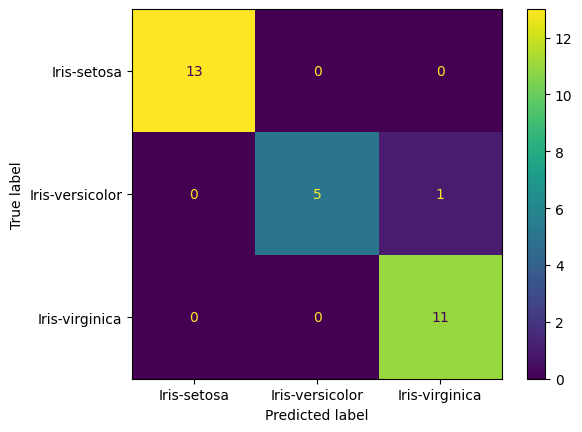

In [20]:
cm =confusion_matrix(y_test,y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=df['Species'].unique())

cm_plot.plot()
plt.savefig("cm.png")
plt.show()

In [22]:
X_test

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
72,6.3,2.5,4.9,1.5
112,6.8,3.0,5.5,2.1
132,6.4,2.8,5.6,2.2
88,5.6,3.0,4.1,1.3
37,4.9,3.1,1.5,0.1
138,6.0,3.0,4.8,1.8
87,6.3,2.3,4.4,1.3
42,4.4,3.2,1.3,0.2
8,4.4,2.9,1.4,0.2
90,5.5,2.6,4.4,1.2


In [23]:
y_test

72     Iris-versicolor
112     Iris-virginica
132     Iris-virginica
88     Iris-versicolor
37         Iris-setosa
138     Iris-virginica
87     Iris-versicolor
42         Iris-setosa
8          Iris-setosa
90     Iris-versicolor
141     Iris-virginica
33         Iris-setosa
59     Iris-versicolor
116     Iris-virginica
135     Iris-virginica
104     Iris-virginica
36         Iris-setosa
13         Iris-setosa
63     Iris-versicolor
45         Iris-setosa
28         Iris-setosa
133     Iris-virginica
24         Iris-setosa
127     Iris-virginica
46         Iris-setosa
20         Iris-setosa
31         Iris-setosa
121     Iris-virginica
117     Iris-virginica
4          Iris-setosa
Name: Species, dtype: object

In [24]:
ans = knn.predict([[6.3,2.5,4.9,1.5]])
print(ans[0])


Iris-virginica


c:\Users\victus\OneDrive\Desktop\ai\sumit\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [25]:
import joblib 
joblib.dump(knn,'knn_model.joblib')
print("SUCCESS")


SUCCESS
